# Step 14 — Non-overlapping five-day evaluation

Daily prediction dates create overlapping five-day outcomes. Here, each schedule keeps only every fifth trading date. We test all five possible starting offsets so the result does not depend on one arbitrary starting day.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "aapl_momentum_sentiment.csv"
OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "non_overlapping_results.csv"
data = pd.read_csv(DATA_PATH, parse_dates=["date"], index_col="date").sort_index()
data = data.loc[:"2024-11-22"].copy()

## Create five schedules

Offset 1 keeps rows 1, 6, 11, and so on. Offset 2 keeps rows 2, 7, 12, and so on. Within each schedule, consecutive prediction targets cover separate five-trading-day intervals.

In [2]:
feature_sets = {
    "Momentum only": ["aapl_momentum_5d"],
    "Tone only": ["average_sentiment_5d"],
    "Momentum + tone": ["aapl_momentum_5d", "average_sentiment_5d"],
}
rows = []

for offset in range(5):
    schedule = data.iloc[offset::5].copy()
    test_size = int(len(schedule) * 0.25)
    test_start = len(schedule) - test_size
    train = schedule.iloc[: test_start - 1].copy()
    test = schedule.iloc[test_start:].copy()
    y_train = train["outperformed"].astype(int)
    y_test = test["outperformed"].astype(int)

    majority_class = int(y_train.mode().iloc[0])
    majority_prediction = pd.Series(majority_class, index=test.index)
    rows.append({
        "Schedule": offset + 1,
        "Model": "Majority baseline",
        "Training rows": len(train),
        "Test rows": len(test),
        "Test start": test.index.min(),
        "Test end": test.index.max(),
        "Accuracy": accuracy_score(y_test, majority_prediction),
        "ROC AUC": 0.5,
    })

    for model_name, features in feature_sets.items():
        model = make_pipeline(StandardScaler(), LogisticRegression(random_state=42))
        model.fit(train[features], y_train)
        prediction = model.predict(test[features])
        probability = model.predict_proba(test[features])[:, 1]
        rows.append({
            "Schedule": offset + 1,
            "Model": model_name,
            "Training rows": len(train),
            "Test rows": len(test),
            "Test start": test.index.min(),
            "Test end": test.index.max(),
            "Accuracy": accuracy_score(y_test, prediction),
            "ROC AUC": roc_auc_score(y_test, probability),
        })

results = pd.DataFrame(rows)
results.to_csv(OUTPUT_PATH, index=False)
results.pivot(index="Schedule", columns="Model", values="Accuracy").round(3)

Model,Majority baseline,Momentum + tone,Momentum only,Tone only
Schedule,,,,
1,0.522,0.478,0.522,0.478
2,0.391,0.478,0.565,0.391
3,0.522,0.565,0.522,0.565
4,0.478,0.609,0.478,0.652
5,0.565,0.522,0.522,0.565


## Summarize across starting offsets

The five schedules are sensitivity checks, not five independent experiments. We report their mean, minimum, and maximum to show how much the starting offset changes the result.

In [3]:
summary = results.groupby("Model").agg(
    mean_accuracy=("Accuracy", "mean"),
    minimum_accuracy=("Accuracy", "min"),
    maximum_accuracy=("Accuracy", "max"),
    mean_roc_auc=("ROC AUC", "mean"),
    minimum_roc_auc=("ROC AUC", "min"),
    maximum_roc_auc=("ROC AUC", "max"),
)
summary.round(3)

,mean_accuracy,minimum_accuracy,maximum_accuracy,mean_roc_auc,minimum_roc_auc,maximum_roc_auc
Model,,,,,,
Majority baseline,0.496,0.391,0.565,0.500,0.500,0.500
Momentum + tone,0.530,0.478,0.609,0.515,0.220,0.629
Momentum only,0.522,0.478,0.565,0.500,0.485,0.508
Tone only,0.530,0.391,0.652,0.592,0.235,0.786


In [4]:
accuracy_table = results.pivot(index="Schedule", columns="Model", values="Accuracy")
pd.Series({
    model: int((accuracy_table[model] > accuracy_table["Majority baseline"]).sum())
    for model in feature_sets
}, name="Schedules beating baseline")

Momentum only      1
Tone only          2
Momentum + tone    3
Name: Schedules beating baseline, dtype: int64

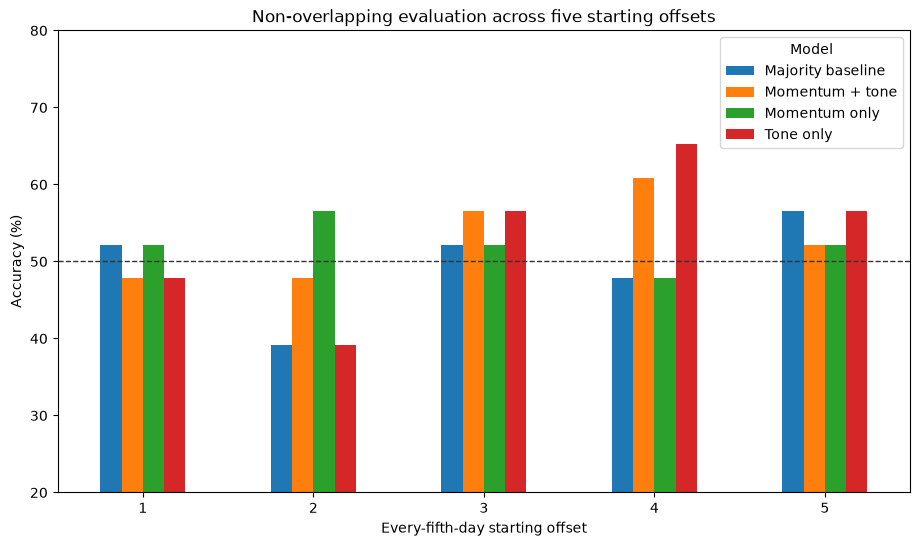

In [5]:
ax = (accuracy_table * 100).plot.bar(figsize=(11, 6), rot=0)
ax.axhline(50, color="#333333", linestyle="--", linewidth=1)
ax.set_ylim(20, 80)
ax.set_xlabel("Every-fifth-day starting offset")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Non-overlapping evaluation across five starting offsets")
plt.show()

## Limitations

Non-overlapping schedules reduce each test set to roughly one-fifth of the daily observations, increasing uncertainty. The schedules use different subsets of the same overall history and should not be treated as independent replications.